In [ ]:
!pip install -q kagglehub
import kagglehub

# Downloads the full datasets to a hidden temp folder
dog_data_path = kagglehub.dataset_download('youssefmohmmed/dogs-skin-diseases-image-dataset')
human_data_path = kagglehub.dataset_download('devdope/skin-disease-raw-dataset')

100%|██████████| 219M/219M [00:01<00:00, 133MB/s]

Extracting files...


100%|██████████| 472M/472M [00:03<00:00, 143MB/s]

Extracting files...


In [ ]:
import os
import shutil

# 1. Create a master folder for your project
os.makedirs('mange_project/Demodicosis', exist_ok=True)
os.makedirs('mange_project/Healthy', exist_ok=True)
os.makedirs('mange_project/Scabies', exist_ok=True)

# 2. Move ONLY the specific folders you need
# For the Dog Dataset: We take Demodicosis and Healthy
shutil.copytree(os.path.join(dog_data_path, 'train/demodicosis'), 'mange_project/Demodicosis', dirs_exist_ok=True)
shutil.copytree(os.path.join(dog_data_path, 'train/Healthy'), 'mange_project/Healthy', dirs_exist_ok=True)

# For the Human Dataset: We take ONLY the Scabies folder
shutil.copytree(os.path.join(human_data_path, 'Raw_Dataset/sc_Scabies_sarna'), 'mange_project/Scabies', dirs_exist_ok=True)

print("Setup Complete: You now have a 'mange_project' folder with only your 3 target classes.")

Setup Complete: You now have a 'mange_project' folder with only your 3 target classes.


# Imports

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Device (GPU is available)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


# Define Transformers (preprocessing + augmentation)

In [ ]:
image_size = 224  # ViT models typically require 224x224 images

train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


## Counting Images Per Folder

In [ ]:
import os

# Path to your organized dataset
organized_path = "/content/mange_project"

print("--- Image Counts in mange_project ---")
# 1. List the folders inside mange_project
for disease_folder in os.listdir(organized_path):
    disease_path = os.path.join(organized_path, disease_folder)

    # 2. Make sure it's a folder, not a file
    if os.path.isdir(disease_path):
        # 3. Count only the images (.jpg, .jpeg, .png)
        images = [f for f in os.listdir(disease_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"{disease_folder}: {len(images)} images")


--- Image Counts in mange_project ---
Healthy: 492 images
Demodicosis: 588 images
Scabies: 270 images


# EDA (Exploratory Data Analysis)

In [ ]:
import pandas as pd
import os

# Updated EDA for Mange & Scabies Project
def get_image_counts(path):
    data = []
    for disease_folder in os.listdir(path):
        disease_path = os.path.join(path, disease_folder)
        if os.path.isdir(disease_path):
            # Count the images
            num_images = len([f for f in os.listdir(disease_path)
                              if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

            # Identify the source correctly
            if disease_folder == "Scabies":
                source = "Human Dataset"
            else:
                source = "Dog Dataset"

            data.append({
                "Source": source,
                "Disease": disease_folder,
                "Count": num_images
            })
    return data

# Refresh the dataframe
image_data = get_image_counts(organized_path)
df = pd.DataFrame(image_data)

## Plot Numbers of Images Per Disease

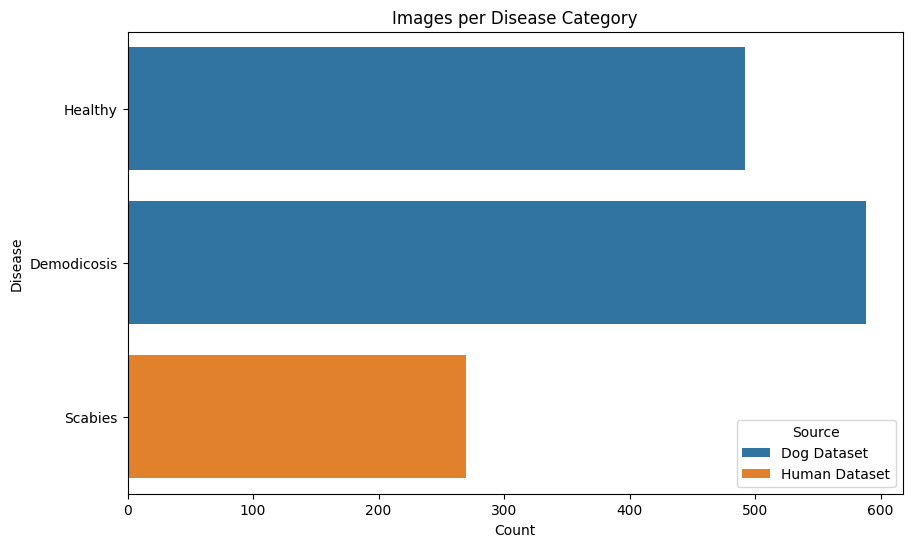

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Count", y="Disease", hue="Source", data=df)
plt.title("Images per Disease Category")
plt.show()

## Class Distribution for Demodectic vs Sarcoptic

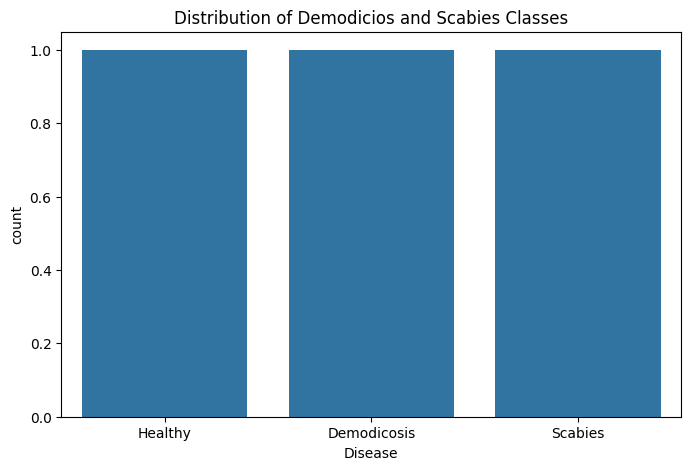

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="Disease", data=df)
plt.title("Distribution of Demodicios and Scabies Classes")
plt.show()

# Dataset Splitting (Train / Validation / Test)

In [ ]:
import random
import os
import shutil

# Paths
source_path = "/content/mange_project"
split_path = "/content/mange_project_split"

# Remove existing split_path to ensure a clean slate
if os.path.exists(split_path):
    shutil.rmtree(split_path)

# Create train, val, test folders with correct disease names
for disease_name in ["Demodicosis", "Scabies", "Healthy"]:
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(split_path, split, disease_name), exist_ok=True)

# Function to split each disease folder
def split_my_data():
    for disease in ["Demodicosis", "Healthy", "Scabies"]:
        disease_path = os.path.join(source_path, disease)
        images = [f for f in os.listdir(disease_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        random.shuffle(images)

        # 70% Train, 15% Val, 15% Test
        n_train = int(0.7 * len(images))
        n_val = int(0.15 * len(images))

        splits = {
            "train": images[:n_train],
            "val": images[n_train:n_train+n_val],
            "test": images[n_train+n_val:]
        }

        for split, split_images in splits.items():
            dest = os.path.join(split_path, split, disease) # 'disease' here matches disease_name in os.makedirs
            for img in split_images:
                shutil.copy(os.path.join(disease_path, img), os.path.join(dest, img))

split_my_data()


# Load Dataset with Pytorch

In [ ]:
import torch
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Path to split dataset
split_path = "/content/mange_project_split"

# Image size for Vision Transformer (ViT expects 224x224)
image_size = 224

# Transformations
train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(root=os.path.join(split_path, "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=os.path.join(split_path, "val"), transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(root=os.path.join(split_path, "test"), transform=val_test_transforms)

# Create DataLoaders
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check dataset info
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")
print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Number of test images: {len(test_dataset)}")


Using device: cuda
Number of classes: 3
Classes: ['Demodicosis', 'Healthy', 'Scabies']
Number of training images: 944
Number of validation images: 201
Number of test images: 205


# Model Building Visiong Transformer

In [ ]:
import torch
import torch.nn as nn

# Vision Transformer from scratch
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=16, embed_dim=768, img_size=224):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, H/patch, W/patch)
        x = x.flatten(2)  # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)  # (B, num_patches, embed_dim)
        return x

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=8, mlp_dim=2048, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Self-attention
        x2 = self.norm1(x)
        x2 = x2.transpose(0, 1)  # MultiheadAttention expects (seq_len, batch, embed_dim)
        attn_out, _ = self.attn(x2, x2, x2)
        x = x + attn_out.transpose(0, 1)
        # MLP
        x = x + self.mlp(self.norm2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, num_classes=3,
                 embed_dim=768, depth=12, num_heads=8, mlp_dim=2048, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, patch_size, embed_dim, img_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        # Transformer encoder blocks
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        cls_output = x[:, 0]  # take the class token
        out = self.head(cls_output)
        return out

# Example: initialize model
num_classes = len(train_dataset.classes)
model = ViT(num_classes=num_classes).to(device)
print(f"Model initialized for {num_classes} categories: {train_dataset.classes}")


Model initialized for 3 categories: ['Demodicosis', 'Healthy', 'Scabies']


# Training ViT from Scratch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# assuming num_classes is already defined from train_dataset.classes
model = ViT(num_classes=num_classes).to(device)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
num_epochs = 20


In [ ]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_acc = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += (outputs.argmax(1) == labels).float().mean().item()

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)

    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_acc += (outputs.argmax(1) == labels).float().mean().item()

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)

    scheduler.step(val_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print(f"Learning rate after epoch {epoch+1}: {optimizer.param_groups[0]['lr']}")


Epoch 1/20 - Training: 100%|██████████| 59/59 [00:31<00:00,  1.84it/s]


Epoch [1/20] Train Loss: 0.9920, Train Acc: 0.5710, Val Loss: 0.6437, Val Acc: 0.6741
Learning rate after epoch 1: 0.0001


Epoch 2/20 - Training: 100%|██████████| 59/59 [00:32<00:00,  1.82it/s]


Epoch [2/20] Train Loss: 0.6291, Train Acc: 0.7299, Val Loss: 0.5881, Val Acc: 0.7126
Learning rate after epoch 2: 0.0001


Epoch 3/20 - Training: 100%|██████████| 59/59 [00:34<00:00,  1.70it/s]


...

Epoch [18/20] Train Loss: 0.1333, Train Acc: 0.9576, Val Loss: 0.2385, Val Acc: 0.9338
Learning rate after epoch 18: 5e-05


Epoch 19/20 - Training: 100%|██████████| 59/59 [00:36<00:00,  1.63it/s]


Epoch [19/20] Train Loss: 0.0522, Train Acc: 0.9809, Val Loss: 0.3062, Val Acc: 0.9338
Learning rate after epoch 19: 5e-05


Epoch 20/20 - Training: 100%|██████████| 59/59 [00:36<00:00,  1.62it/s]


Epoch [20/20] Train Loss: 0.0414, Train Acc: 0.9894, Val Loss: 0.2544, Val Acc: 0.9338
Learning rate after epoch 20: 5e-05


## Test Set Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n")
print(cm)


Classification Report:

              precision    recall  f1-score   support

 Demodicosis       0.96      0.89      0.92        89
     Healthy       0.88      0.97      0.92        75
     Scabies       0.93      0.90      0.91        41

    accuracy                           0.92       205
   macro avg       0.92      0.92      0.92       205
weighted avg       0.93      0.92      0.92       205

Confusion Matrix:

[[79  8  2]
 [ 1 73  1]
 [ 2  2 37]]


# Visualization Confusion Matrix

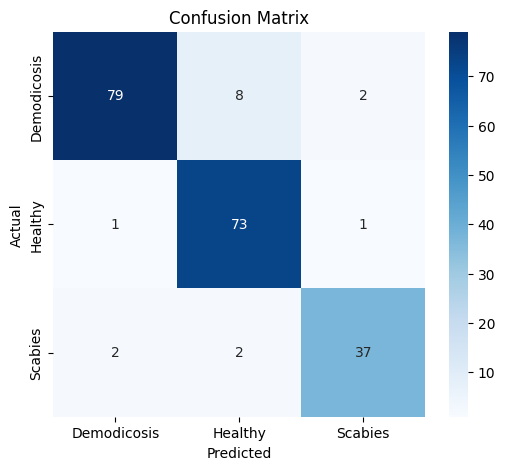

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Save the Trained Model

In [ ]:
# Save model
torch.save(model.state_dict(), "/content/vit_mange_model.pth")
print("Model saved successfully!")


Model saved successfully!


## Load Model for Interface

In [ ]:
# Load model
model = ViT(num_classes=num_classes).to(device)
model.load_state_dict(torch.load("/content/vit_mange_model.pth"))
model.eval()



ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x TransformerEncoderBlock(
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=768, out_features=2048, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=2048, out_features=768, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=768, out_features=3, bias=True)
)

## Default Query Image

In [ ]:
import random

# Dynamically select an image path from the test_dataset
# The test_dataset.samples is a list of (image_path, class_id) tuples
img_path, _ = random.choice(test_dataset.samples)

print("Predicted Disease:", predict_image(img_path))

Predicted Disease: Healthy


# Prediction Function

In [ ]:
from PIL import Image
from torchvision import transforms

# Define same transforms as validation
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def predict_image(img_path):
    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        pred = output.argmax(1).item()
    return train_dataset.classes[pred]

# Predict
print("Predicted Disease:", predict_image(img_path))


Predicted Disease: Healthy


## Test Case (Detect Image Path Exists)

In [ ]:
import os

if os.path.exists(img_path):
    print("Predicted Disease:", predict_image(img_path))
else:
    print(f"File not found: {img_path}")


Predicted Disease: Healthy


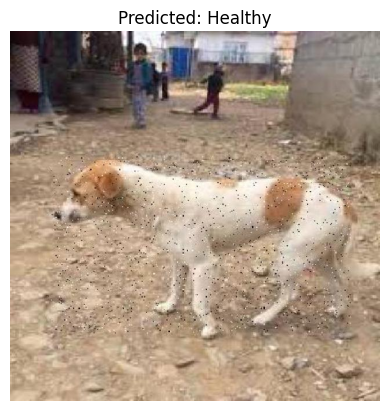

In [ ]:
import matplotlib.pyplot as plt

image = Image.open(img_path).convert("RGB")
plt.imshow(image)
plt.title("Predicted: " + predict_image(img_path))
plt.axis("off")
plt.show()


## Disease Description Information

In [ ]:
disease_info = {
 # Dogs
    "Demodicosis": "A skin condition caused by Demodex mites. It often results in hair loss, redness, and scaling in dogs.",
    "Scabies": "A highly contagious skin infestation by the Sarcoptes scabiei mite, causing intense itching and a pimple-like rash.",
    "Healthy": "The skin with no visible signs of parasitic infestation or infection."
}


## Updating the Prediction Function

In [ ]:
def predict_image_with_description(img_path):
    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        pred_idx = output.argmax(1).item()
    pred_class = train_dataset.classes[pred_idx]
    pred_description = disease_info.get(pred_class, "No description available")
    return pred_class, pred_description


## Run Prediction

### Query Image Path

In [ ]:
import os


test_folder = "/content/mange_project_split/test/Scabies"


target_file = "Sarna (138).jpg"
img_path = os.path.join(test_folder, target_file)

if os.path.exists(img_path):
    print(f"✅ Target Loaded: {img_path}")
else:

    files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_path = os.path.join(test_folder, files[0])
    print(f"⚠️ Using backup: {img_path}")

✅ Target Loaded: /content/mange_project_split/test/Scabies/Sarna (138).jpg


In [ ]:

pred_class, pred_desc = predict_image_with_description(img_path)
print(f"Predicted Disease: {pred_class}")
print(f"Disease Info: {pred_desc}")


Predicted Disease: Scabies
Disease Info: A highly contagious skin infestation by the Sarcoptes scabiei mite, causing intense itching and a pimple-like rash.


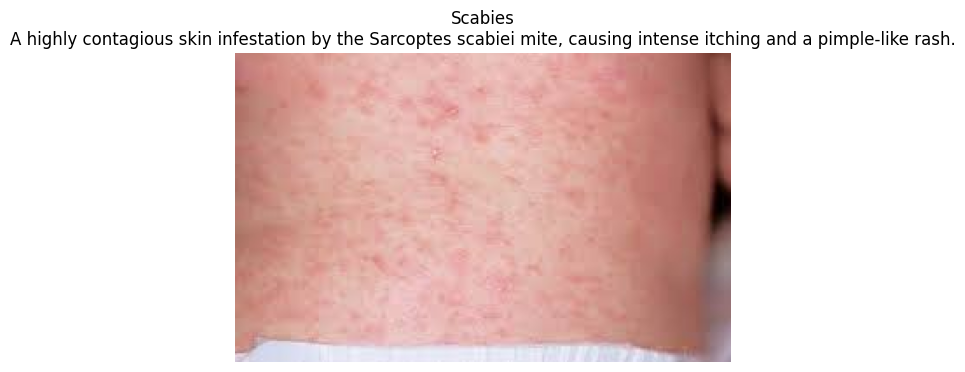

In [ ]:
import matplotlib.pyplot as plt

image = Image.open(img_path).convert("RGB")
plt.imshow(image)
plt.title(f"{pred_class}\n{pred_desc}")
plt.axis("off")
plt.show()


## Inference Pipeline

In [ ]:
test_samples = [
    "/content/mange_project_split/test/Scabies/Sarna (138).jpg",
    "/content/mange_project_split/test/Demodicosis/1-15-_png_jpg.rf.ec602a0bc1b8b9e477b0b77d06398bae.jpg",
    "/content/mange_project_split/test/Healthy/dogs_278_jpg.rf.a075038c0fb5e72f65b4ac8f4911b312.jpg"
]

print("--- Starting Final Multi-Class Validation for Submission ---")
print("This test verifies the model can distinguish between all three target classes.\n")

for img_path in test_samples:
    if os.path.exists(img_path):

        run_final_inference(img_path)
        print("-" * 50)
    else:
        print(f"⚠️ File not found: {img_path}. Please check the filename.")

--- Starting Final Multi-Class Validation for Submission ---
This test verifies the model can distinguish between all three target classes.

Analysis Result: Scabies
Clinical Note: A highly contagious skin infestation by the Sarcoptes scabiei mite, causing intense itching and a pimple-like rash.
--------------------------------------------------
Analysis Result: Demodicosis
Clinical Note: A skin condition caused by Demodex mites. It often results in hair loss, redness, and scaling in dogs.
--------------------------------------------------
Analysis Result: Healthy
Clinical Note: The skin with no visible signs of parasitic infestation or infection.
--------------------------------------------------
